In [ ]:
import numpy as np

def dft_matrix(N):
    F_N = np.zeros((N, N), dtype=complex)
    for k in range(N):
        for j in range(N):
            F_N[k, j] = np.exp(-2j * np.pi * k * j / N)

    return F_N

def shift_matrix(N, shifts):

    I_N = np.eye(N, dtype=int)

    # Apply the shifts
    P_N = np.roll(I_N, shifts, axis=1)

    return P_N
def Fourier_norm(F_N):
  k= F_N.transpose()
  for i in range(len(k)):
    print(np.linalg.norm(F_N[i]))

def circulant_matrix(c):
    N = len(c)
    C_N = np.zeros((N, N),dtype=int)

    for i in range(N):
        C_N[i] = np.roll(c, i)

    return C_N


def verify_eigenvalues(N, shifts):
    # Define the Fourier Matrix F_N
    F_N = dft_matrix(N)
    Fourier_norm(F_N)
    print("fourier matrix")
    print(F_N)

    # Obtain the shift matrix P_N
    P_N = shift_matrix(N, shifts)

    # Obtain the eigenvalues of P_N
    eigvals_P_N,eigen_vecs_P_N = np.linalg.eig(P_N)

    # Define a sample circulant matrix C_N
    c = [2,-1,0,-1]
    C_N = circulant_matrix(c)
    print(C_N)
    multiply(F_N,c)

    # Obtain the eigenvalues of C_N
    eigvals_C_N,eigen_vec_C_N = np.linalg.eig(C_N)



    return eigvals_P_N,eigen_vecs_P_N, eigvals_C_N,eigen_vec_C_N

def multiply(F_N, c):
    c = np.array(c).reshape(-1, 1)
    x = np.dot(F_N, c)
    print("Multiply")
    print(x)

def Normalized_F_N_matrix(N):
    F_N_normal = np.zeros((N, N), dtype=complex)
    for k in range(N):
        for j in range(N):
            F_N_normal[k, j] = np.exp(-2j * np.pi * k * j / N)
            F_N_normal[k,j]=np.divide(F_N_normal[k,j],2)

    print("normalized FN")
    print(F_N_normal)

N = int(input("Enter the value of N: "))
shifts = int(input("Enter the number of shifts: "))

Normalized_F_N_matrix(N)
P_N = shift_matrix(N, shifts)
print("Shift Matrix P_N with {} shifts:".format(shifts))
print(P_N)

eigvals_P_N,eigen_vecs_P_N,eigvals_C_N,eigen_vecs_C_N = verify_eigenvalues(N, shifts)

print("\nEigenvalues of P_N:")
print(eigvals_P_N)

print("eigen vectors opf P_N")
print(eigen_vecs_P_N)
print("\nEigenvalues of C_N:")
print(eigvals_C_N)
print("Eigen vectors of C_N")
print(eigen_vecs_C_N)
print(np.linalg.norm(eigen_vecs_C_N))
print(np.linalg.norm(eigen_vecs_P_N))


Enter the value of N: 4
Enter the number of shifts: 1
normalized FN
[[ 5.00000000e-01+0.0000000e+00j  5.00000000e-01+0.0000000e+00j
   5.00000000e-01+0.0000000e+00j  5.00000000e-01+0.0000000e+00j]
 [ 5.00000000e-01+0.0000000e+00j  3.06161700e-17-5.0000000e-01j
  -5.00000000e-01-6.1232340e-17j -9.18485099e-17+5.0000000e-01j]
 [ 5.00000000e-01+0.0000000e+00j -5.00000000e-01-6.1232340e-17j
   5.00000000e-01+1.2246468e-16j -5.00000000e-01-1.8369702e-16j]
 [ 5.00000000e-01+0.0000000e+00j -9.18485099e-17+5.0000000e-01j
  -5.00000000e-01-1.8369702e-16j  2.75545530e-16-5.0000000e-01j]]
Shift Matrix P_N with 1 shifts:
[[0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]
 [1 0 0 0]]
2.0
2.0
2.0
2.0
fourier matrix
[[ 1.0000000e+00+0.0000000e+00j  1.0000000e+00+0.0000000e+00j
   1.0000000e+00+0.0000000e+00j  1.0000000e+00+0.0000000e+00j]
 [ 1.0000000e+00+0.0000000e+00j  6.1232340e-17-1.0000000e+00j
  -1.0000000e+00-1.2246468e-16j -1.8369702e-16+1.0000000e+00j]
 [ 1.0000000e+00+0.0000000e+00j -1.0000000e+00-1.2246468e

In [ ]:
import numpy as np

def dft_matrix(N):
    F_N = np.zeros((N, N), dtype=complex)
    for k in range(N):
        for j in range(N):
            F_N[k, j] = np.exp(-2j * np.pi * k * j / N)
    return F_N

def idft_matrix(N):
    F_N_inv = np.zeros((N, N), dtype=complex)
    for k in range(N):
        for j in range(N):
            F_N_inv[k, j] = np.exp(2j * np.pi * k * j / N) / N
    return F_N_inv

def hadamard_product(a, b):
    return np.multiply(a, b)

def circular_convolution(a, b):
    N = len(a)
    c = np.zeros(N)
    for m in range(N):
        c[m] = sum(a[n] * b[(m - n) % N] for n in range(N))
    return c

# Example usage
a = np.array([1, 2, 3, 4])
b = np.array([0, 1, 0, 0])

N = len(a)

conv_direct = circular_convolution(a, b)
print("Direct Circular Convolution:")
print(conv_direct)


F_N = dft_matrix(N)
a_fft = np.dot(F_N, a)
b_fft = np.dot(F_N, b)

product_fft = hadamard_product(a_fft, b_fft)


F_N_inv = idft_matrix(N)
conv_fft = np.dot(F_N_inv, product_fft)

print("\nConvolution via Hadamard Product in Fourier Domain:")
print(np.real(conv_fft))


Direct Circular Convolution:
[4. 1. 2. 3.]

Convolution via Hadamard Product in Fourier Domain:
[4. 1. 2. 3.]


[[5.1 3.5]
 [4.9 3. ]
 [4.7 3.2]
 [4.6 3.1]
 [5.  3.6]
 [5.4 3.9]
 [4.6 3.4]
 [5.  3.4]
 [4.4 2.9]
 [4.9 3.1]
 [5.4 3.7]
 [4.8 3.4]
 [4.8 3. ]
 [4.3 3. ]
 [5.8 4. ]
 [5.7 4.4]
 [5.4 3.9]
 [5.1 3.5]
 [5.7 3.8]
 [5.1 3.8]
 [5.4 3.4]
 [5.1 3.7]
 [4.6 3.6]
 [5.1 3.3]
 [4.8 3.4]
 [5.  3. ]
 [5.  3.4]
 [5.2 3.5]
 [5.2 3.4]
 [4.7 3.2]
 [4.8 3.1]
 [5.4 3.4]
 [5.2 4.1]
 [5.5 4.2]
 [4.9 3.1]
 [5.  3.2]
 [5.5 3.5]
 [4.9 3.6]
 [4.4 3. ]
 [5.1 3.4]
 [5.  3.5]
 [4.5 2.3]
 [4.4 3.2]
 [5.  3.5]
 [5.1 3.8]
 [4.8 3. ]
 [5.1 3.8]
 [4.6 3.2]
 [5.3 3.7]
 [5.  3.3]
 [7.  3.2]
 [6.4 3.2]
 [6.9 3.1]
 [5.5 2.3]
 [6.5 2.8]
 [5.7 2.8]
 [6.3 3.3]
 [4.9 2.4]
 [6.6 2.9]
 [5.2 2.7]
 [5.  2. ]
 [5.9 3. ]
 [6.  2.2]
 [6.1 2.9]
 [5.6 2.9]
 [6.7 3.1]
 [5.6 3. ]
 [5.8 2.7]
 [6.2 2.2]
 [5.6 2.5]
 [5.9 3.2]
 [6.1 2.8]
 [6.3 2.5]
 [6.1 2.8]
 [6.4 2.9]
 [6.6 3. ]
 [6.8 2.8]
 [6.7 3. ]
 [6.  2.9]
 [5.7 2.6]
 [5.5 2.4]
 [5.5 2.4]
 [5.8 2.7]
 [6.  2.7]
 [5.4 3. ]
 [6.  3.4]
 [6.7 3.1]
 [6.3 2.3]
 [5.6 3. ]
 [5.5 2.5]
 [5.5 2.6]

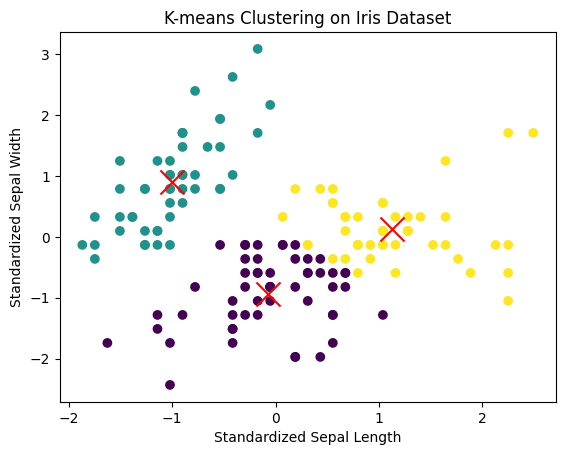

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

def initialize_centroids(X, k):
    """Randomly initialize the centroids by choosing k unique points from the dataset."""
    indices = np.random.choice(X.shape[0], k, replace=False)
    return X[indices]

def compute_distances(X, centroids, p=2):
    """Compute the Minkowski distance from each point to each centroid."""
    distances = np.zeros((X.shape[0], centroids.shape[0]))
    for i, centroid in enumerate(centroids):
        distances[:, i] = np.sum(np.abs(X - centroid)**p, axis=1)**(1/p)
    return distances

def assign_clusters(distances):
    """Assign each point to the closest centroid."""
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, k):
    """Update the centroids to be the mean of the points in each cluster."""
    centroids = np.zeros((k, X.shape[1]))
    for i in range(k):
        points = X[labels == i]
        if len(points) > 0:
            centroids[i] = points.mean(axis=0)
    return centroids

def kmeans(X, k, max_iterations=100, tol=1e-4, p=2, n_init=10):
    """Perform k-means clustering with multiple initializations."""
    best_inertia = np.inf
    best_labels = None
    best_centroids = None

    for _ in range(n_init):
        centroids = initialize_centroids(X, k)
        for _ in range(max_iterations):
            old_centroids = centroids
            distances = compute_distances(X, centroids, p)
            labels = assign_clusters(distances)
            centroids = update_centroids(X, labels, k)
            if np.all(np.abs(centroids - old_centroids) < tol):
                break

        inertia = np.sum(np.min(compute_distances(X, centroids, p), axis=1)**2)
        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels
            best_centroids = centroids

    return best_labels, best_centroids


iris = load_iris()
X = iris.data
y = iris.target
print(X[:, :2])
print(y)

scaler = StandardScaler()
X_std = scaler.fit_transform(X[:, :2])


k = 3
p = 2
n_init = 10
labels, centroids = kmeans(X_std, k, p=p, n_init=n_init)
print(centroids)
print(labels)
plt.scatter(X_std[:, 0], X_std[:, 1], c=labels, cmap='viridis', marker='o')
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='red', marker='x')
plt.xlabel('Standardized Sepal Length')
plt.ylabel('Standardized Sepal Width')
plt.title('K-means Clustering on Iris Dataset')
plt.show()


In [ ]:

centroid_x = centroids[:, 0]
centroid_y = centroids[:, 1]
print("Centroid X coordinates:", centroid_x)
print("Centroid Y coordinates:", centroid_y)

Centroid X coordinates: [-1.01457897 -0.05021989  1.13597027]
Centroid Y coordinates: [ 0.85326268 -0.88337647  0.08842168]


In [ ]:


import numpy as np
from scipy.linalg import orthogonal_procrustes

def orthogonal_procrustes(X, Y):
    """
    Computes the orthogonal Procrustes solution for two matrices X and Y.

    Args:
        X: A numpy array of shape (m, n).
        Y: A numpy array of shape (m, n).

    Returns:
        A tuple (U, V, s) where:
            U: The orthogonal matrix that aligns X to Y.
            V: The orthogonal matrix that aligns Y to X.
            s: The scaling factor.
    """


    U, s, V_transpose = np.linalg.svd(X.T @ Y)
    V = V_transpose.T

    return U, V, s

# Example usage
angle = np.pi / 3


X = iris.data[:,:2]


Y = np.dot(np.array([[np.cos(angle), -np.sin(angle)],
                     [np.sin(angle), np.cos(angle)]]), X.T).T






U, V, s = orthogonal_procrustes(X, Y)

print("Orthogonal matrix U:")
print(U)

print("Orthogonal matrix V:")
print(V)

print("Scaling factor s:")
print(s)



Orthogonal matrix U:
[[ 0.88843566  0.45900118]
 [ 0.45900118 -0.88843566]]
Orthogonal matrix V:
[[ 0.04671115  0.99890844]
 [ 0.99890844 -0.04671115]]
Scaling factor s:
[6605.05021125   49.19978875]


In [ ]:


import numpy as np
UV_transpose = np.dot(U, V.T)

print("UV^T:")
print(UV_transpose)




UV^T:
[[ 0.5        0.8660254]
 [-0.8660254  0.5      ]]


In [ ]:


import numpy as np

def is_orthogonal(matrix):
  """
  Checks if a matrix is orthogonal.

  Args:
    matrix: A numpy array representing the matrix.

  Returns:
    True if the matrix is orthogonal, False otherwise.
  """
  return np.allclose(np.dot(matrix, matrix.T), np.eye(matrix.shape[0]))


is_orthogonal_UV_transpose = is_orthogonal(UV_transpose)

print("Is UV^T orthogonal?:", is_orthogonal_UV_transpose)


Is UV^T orthogonal?: True


In [ ]:
Q_Y_T = np.dot(UV_transpose, Y.T)
print(Q_Y_T)

[[5.1 4.9 4.7 4.6 5.  5.4 4.6 5.  4.4 4.9 5.4 4.8 4.8 4.3 5.8 5.7 5.4 5.1
  5.7 5.1 5.4 5.1 4.6 5.1 4.8 5.  5.  5.2 5.2 4.7 4.8 5.4 5.2 5.5 4.9 5.
  5.5 4.9 4.4 5.1 5.  4.5 4.4 5.  5.1 4.8 5.1 4.6 5.3 5.  7.  6.4 6.9 5.5
  6.5 5.7 6.3 4.9 6.6 5.2 5.  5.9 6.  6.1 5.6 6.7 5.6 5.8 6.2 5.6 5.9 6.1
  6.3 6.1 6.4 6.6 6.8 6.7 6.  5.7 5.5 5.5 5.8 6.  5.4 6.  6.7 6.3 5.6 5.5
  5.5 6.1 5.8 5.  5.6 5.7 5.7 6.2 5.1 5.7 6.3 5.8 7.1 6.3 6.5 7.6 4.9 7.3
  6.7 7.2 6.5 6.4 6.8 5.7 5.8 6.4 6.5 7.7 7.7 6.  6.9 5.6 7.7 6.3 6.7 7.2
  6.2 6.1 6.4 7.2 7.4 7.9 6.4 6.3 6.1 7.7 6.3 6.4 6.  6.9 6.7 6.9 5.8 6.8
  6.7 6.7 6.3 6.5 6.2 5.9]
 [3.5 3.  3.2 3.1 3.6 3.9 3.4 3.4 2.9 3.1 3.7 3.4 3.  3.  4.  4.4 3.9 3.5
  3.8 3.8 3.4 3.7 3.6 3.3 3.4 3.  3.4 3.5 3.4 3.2 3.1 3.4 4.1 4.2 3.1 3.2
  3.5 3.6 3.  3.4 3.5 2.3 3.2 3.5 3.8 3.  3.8 3.2 3.7 3.3 3.2 3.2 3.1 2.3
  2.8 2.8 3.3 2.4 2.9 2.7 2.  3.  2.2 2.9 2.9 3.1 3.  2.7 2.2 2.5 3.2 2.8
  2.5 2.8 2.9 3.  2.8 3.  2.9 2.6 2.4 2.4 2.7 2.7 3.  3.4 3.1 2.3 3.  2.5
  2.6 3.  2.

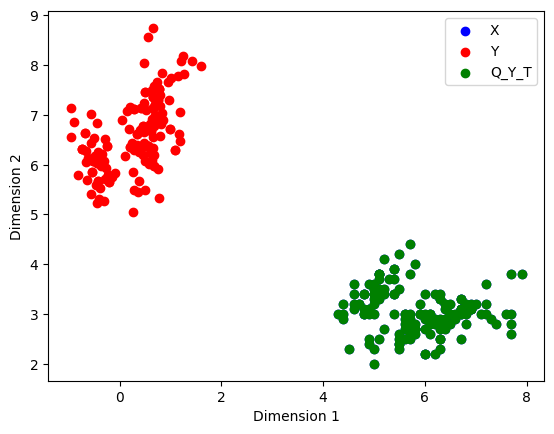

In [ ]:


import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], label='X', color='blue')
plt.scatter(Y[:, 0], Y[:, 1], label='Y', color='red')
plt.scatter(Q_Y_T[0, :], Q_Y_T[1, :], label='Q_Y_T', color='green')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.show()


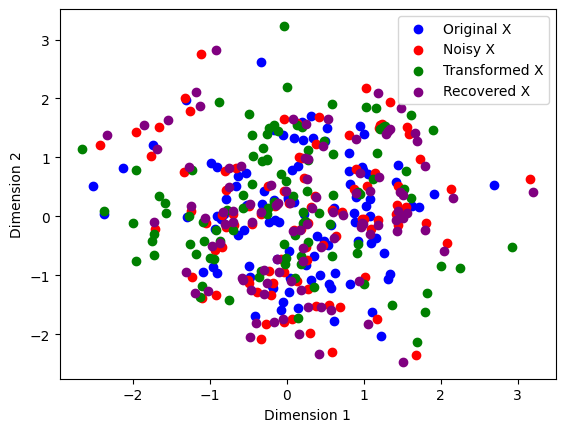

In [ ]:


import numpy as np
import matplotlib.pyplot as plt


original_data = np.random.normal(loc=0, scale=1, size=(100, 2))
noise = np.random.normal(loc=0, scale=0.5, size=(100, 2))
noisy_data = original_data + noise

U, V, s = orthogonal_procrustes(original_data, noisy_data)
transformed_data = np.dot(U, noisy_data.T).T


recovered_data = np.dot(V, transformed_data.T).T

# Plot original and noisy data
plt.scatter(original_data[:, 0], original_data[:, 1], label='Original X', color='blue')
plt.scatter(noisy_data[:, 0], noisy_data[:, 1], label='Noisy X', color='red')

# Plot transformed X and recovered X
plt.scatter(transformed_data[:, 0], transformed_data[:, 1], label='Transformed X', color='green')
plt.scatter(recovered_data[:, 0], recovered_data[:, 1], label='Recovered X', color='purple')

plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.show()
